In [1]:
import pandas as pd
import numpy as np
import psutil
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import spearmanr


from alibi.explainers import ALE
from sklearn.inspection import permutation_importance

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

import seaborn as sns
import matplotlib.pyplot as plt
import altair as alt

from sklearn.linear_model import Ridge
import time
from copy import deepcopy

from collections import defaultdict
from joblib import Parallel, delayed


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
group_size = 7 # Number of top features to select

feature_combination_acc Function Activated: Creating combinations of important attributes by adding model score values...
grouped_weights_valimp Function Activated: Calculating weights of Important Features...
grouped_weights Function Activated: Calculating weights of Important Features...
weighticient and Accuracy Calculated. Data Groups Created According to the Number of Combinational Elements...


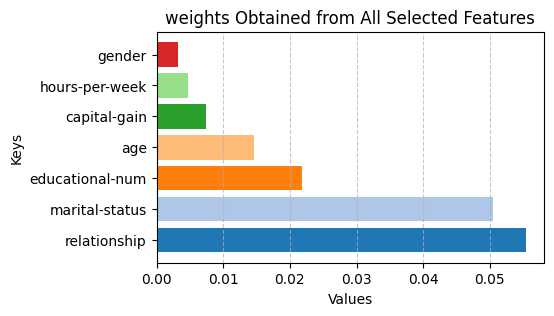

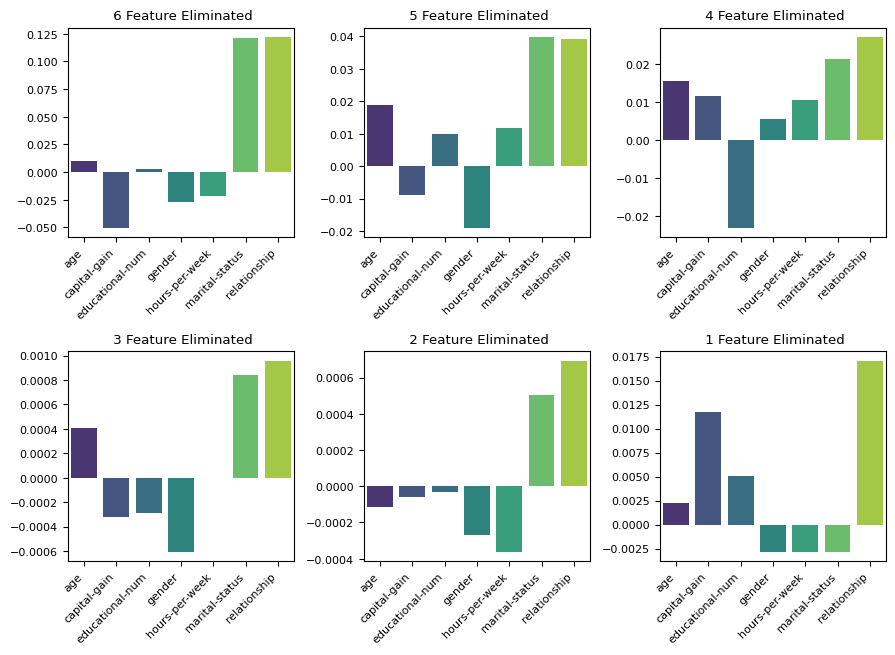



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



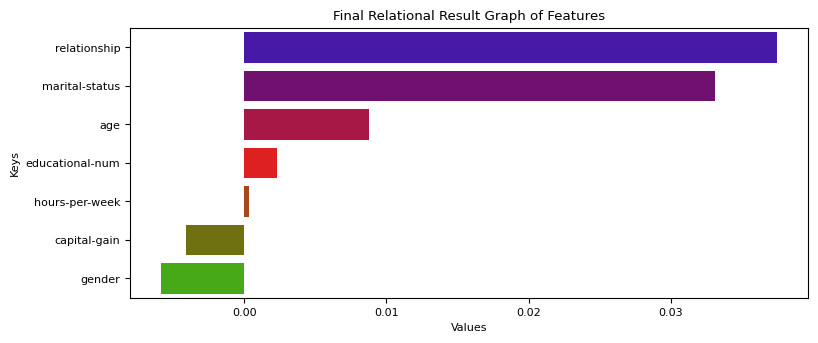

In [3]:

class CalcFeatureWeight:
    def __init__(self,data_path,mdl):
        self.vs = data_path
        self.step=1
        self.data_f = pd.read_csv(self.vs)
        self.df2 = None
        self.df_norm = None
        self.num_of_data= len(self.data_f)
        self.pick_model = mdl
        self.num_cpus= psutil.cpu_count(logical=False)
        self.paramGrid = [ {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}]
        self.b = False
        self.avg_list = None
        self.cols = None
        self.features = None
        self.acc_select = None
        self.grouped_weight_data = None
        self.grouped_weight_data_nonzero_valimp = None
        self.grouped_weight_data_nonzero = None
        self.data_acc_weight=[]
        self.data_acc_weight_sorted= None
        self.new_weight_format = None
        self.alg_consistency=0
        self.num_of_class =0
        self.num_of_feature=0

        self.prepare_data()
        self.select_features()
        self.combFeatures()
        self.algorithmConsistency()
        self.showGraphs()


    def prepare_data(self):
        class_element = self.data_f.iloc[:, -1].copy()
        feature_elements = self.data_f.iloc[:, :-1].copy()
        scaler = MinMaxScaler()
        feature_elements_normalize = pd.DataFrame(scaler.fit_transform(feature_elements), columns=feature_elements.columns)
        self.df_norm = pd.concat([feature_elements_normalize, class_element], axis=1)
        self.num_of_class = np.unique(self.df_norm['class']).shape[0]
        averages = self.df_norm.groupby('class').mean()
        self.avg_list = averages.values.tolist()
        self.cols = self.df_norm.columns.tolist()
        self.num_of_feature = len(self.data_f.columns) - 1


    @staticmethod
    def regression_ridge(df_data, features, grid):
        base_model = Ridge()
        data = df_data.values.tolist()
        # Find the best result by testing different alpha values with GridSearchCV
        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=grid,
            cv=5,
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )

        # X: Features only (excluding accuracy rates)  y: accuracy rates
        X = [item[:-1] for item in data]
        y = [item[-1] for item in data]
        # train the regression model, get the best model and score
        grid_search.fit(X, y)

        # Get the best model and score
        best_model = grid_search.best_estimator_
        # Get and return the weights associated with the regression
        weights = dict(zip(features[:-1], np.round(best_model.coef_, 9)))
        return weights

    @staticmethod
    def feature_accuracy_weight(params, grid, selected_features):
        dataframe, model, comb_select_feature = params
        # Obtain dataframe with only selected features
        dataframe = dataframe[selected_features]
        selected_all_feature = dataframe.columns.tolist()
        d_f = dataframe.loc[:, comb_select_feature].copy()
        y = d_f["class"]
        X = d_f.drop(columns=["class"])  # Only independent variables
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

        # Scaling data
        scaler = MinMaxScaler()
        scaler.fit(X_train)
        X_train = scaler.transform(X_train)
        X_test = scaler.transform(X_test)

        # Train the model and make predictions
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test) # Predict on test data
        acc = accuracy_score(y_test, y_pred)  # Calculate the Accuracy of all features

        # Add prediction probabilities to the last column of X_test and return as dataframe
        X_test_df = pd.DataFrame(X_test, columns=X.columns)

        # Assign 0 for columns that are not in the incoming combination.
        for column in dataframe.columns:
            if column not in comb_select_feature :
                X_test_df[column] = 0
        X_test_df = X_test_df[dataframe.columns[:-1]]
        # We take predictions as class data
        X_test_df["class"] = y_pred
        weights =  CalcFeatureWeight.regression_ridge(X_test_df, selected_all_feature, grid)
        return weights, acc


    @staticmethod
    def feature_accuracy(params):
        dataframe,model,features = params
        #Predict the model by taking the full set of features.
        #This estimate will be used to calculate the importance of the features.
        d_f = dataframe.loc[:,features]
        y = d_f["class"]  # Dependent variables
        X = d_f.drop(columns=["class"])  #Independent variables
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
        scaler = MinMaxScaler()
        scaler.fit(X_train)
        X_train = scaler.transform(X_train)
        X_test = scaler.transform(X_test)

        # Train model, make test data predictions, calculate accuracy rate
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        return acc

    # Combinational difference sum function
    def comb_diff_total(self, feature_maps):
        feature_maps = np.array(feature_maps).T  # Take transpose to work on a column basis
        diffs = np.abs(feature_maps[:, :, np.newaxis] - feature_maps[:, np.newaxis, :])  # Calculate diffs
        # Take only triangular matrix differences (count each pair once)
        triu_indices = np.triu_indices(diffs.shape[1], k=1)  # Get the indices of the upper triangular matrix
        result = np.sum(diffs[:, triu_indices[0], triu_indices[1]], axis=1)  # Take the sum of the upper triangle differences
        return result

    #Cluster the ordered features we obtained with our algorithm into groups
    def grouping(self, list, n, step):
        k = [list[i:i + n] for i in range(0, len(list) - n + 1, step)]
        for j in k:
            j.append('class')
        return k


    def important_feature(self, d_f, group):
        bo_oz = []
        gs = 12  # Number of groups to be selected

        # Take the group of sorted features by a certain number (gs).
        params = [(d_f, self.pick_model, features) for features in group[:gs]]

        #Parallelization with Joblib
        b1 = Parallel(n_jobs=-1)(
            delayed(CalcFeatureWeight.feature_accuracy)(param) for param in params
        )

        bo_oz = list(zip(b1, group[:gs]))

        # Sort the tuple data in the list from largest to smallest according to accuracy.
        selected = sorted(bo_oz, key=lambda x: x[0], reverse=True)
        return selected[0][1]

    # Create groups of 2, 3, ... n combinations where a particular feature is not present.
    # For example, for the list [a,b,c], combinations without a: [b], [c], [bc], etc.
    def eliminated_by_group_n(self, list):
        groups = {}
        for l in list:
            key = len(l)
            if key not in groups:
                groups[key] = []
            groups[key].append(l)

        # Convert the values in the dictionary to a list.
        result = list(groups.values())
        return result

    # Cyclic subdirectory combination
    # Create combinations from 1 to n for each feature by shifting on the features selected by our algorithm.
    # This reduces the computational cost by eliminating unnecessary combinations and ensures optimal results in the regression calculation
    def generate_combinations(self, properties):
        n = len(properties)
        all_combinations = []  # Create an empty list to store all combinations.
        for i in range(n):
            rotated_properties = properties[i:] + properties[:i]
            for j in range(1, n):
                combination = rotated_properties[:j]
                combination.sort()
                if combination != properties:
                    all_combinations.append(combination)  # Add the generated combination to the list.
        return all_combinations  # Return the list with all combinations.

    #Convert our combination of properties into a combination of values.
    #Assign the value 0 to the property that does not exist in the combination, and the value that depends on the property to the value that does exist.
    def convert_to_values(self, properties, values, combination):
        value_dict = dict(zip(properties, values))
        return [value_dict[item] if item in combination else 0 for item in properties]


    def feature_combination_acc(self, d_f, features, df_feature_val):
        print("feature_combination_acc Function Activated: Creating combinations of important attributes by adding model score values...")

        df_feature_val = df_feature_val[features[:-1]]
        values = df_feature_val.iloc[0].values

        # Combinations are created
        combinations = self.generate_combinations(features[:-1])

        # Convert combinations to values
        values_combinations = [self.convert_to_values(features[:-1], values, combo) for combo in combinations]

        result_df = pd.DataFrame(values_combinations, columns=features[:-1])

        non_zero_columns_list = []
        for _, row in result_df.iterrows():
            non_zero_columns = row[row != 0].index.tolist()
            non_zero_columns_list.append(non_zero_columns)

        imp_feature_comb = non_zero_columns_list

        model = deepcopy(self.pick_model)
        for ook in imp_feature_comb:
            ook.append('class')

        # Accuracy calculation to be used in parallelization
        def calc_acc(features):
            model_copy = deepcopy(model)
            params = (d_f, model_copy, features)
            return CalcFeatureWeight.feature_accuracy_weight(params, self.paramGrid, self.features)

        # Parallelization with Joblib
        results = Parallel(n_jobs=-1)(delayed(calc_acc)(features) for features in imp_feature_comb)
        # the weights of the combination and the accuracy values of the respective combination are added together
        imp_feat_comb_acc_weight, on_oz_komb_acc = zip(*results)
        result1 = [[sublist[:-1], value] for sublist, value in zip(imp_feature_comb, imp_feat_comb_acc_weight)]
        result2 = [sublist[:-1]+ [value] for sublist, value in zip(imp_feature_comb, on_oz_komb_acc)]
        return result1, result2

    '''
    This function calculates the weights of the groups passed to it in dictionary format
    {combinationElementNumber:[[combination1], [combination2], [combination3]]} and passes them to the stack.
    * The combination group it receives at the end is the dictionary group including all combinations.
    * Receives and processes groups of combinations in sequence.
    * The regression calculation will allow us to obtain the best weights from the acc scores in the combinational groups.
    '''
    @staticmethod
    def regression_compute_Ridge(group, features, acc, grid):
        zero_count, group = group
        base_model = Ridge()

        # Find the best result by testing different alpha values with GridSearchCV
        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=grid,
            cv=3,
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )

        X = [item[:-1] for item in group]  # Features only (except accuracy rates)
        X.append([1] * len(features))  # A combination that incorporates all selected features

        y = [item[-1] for item in group]  # Get accuracy rates
        y.append(acc)  # Add the accuracy of all selected features

        # Train the model and check the best score
        grid_search.fit(X, y)

        # Get the best model and score
        best_model = grid_search.best_estimator_

        # Get weights and return
        weights = dict(zip(features, np.round(best_model.coef_, 9)))
        return zero_count, weights

    # This function groups feature combinations according to their length
    # (e.g. combinations of 1, 2, ..., n) and sum the weights in each combination group by feature.
    def grouped_weights_valimp(self, eliminated_element_weight, selected_all_feature_weights):
            print("grouped_weights_valimp Function Activated: Calculating weights of Important Features...")
            grouped_data = defaultdict(list)

            for item in eliminated_element_weight:
                length = len(item[0])  # Number of combinations
                grouped_data[length].append(item)

            result = defaultdict(lambda: defaultdict(float))

            for group_size, items in grouped_data.items():
                for _, weights in items:
                    for feature, value in weights.items():
                        result[group_size][feature] += value

            result_dict = {(group_size - key): dict(value) for key, value in result.items()}
            result_dict[0] = selected_all_feature_weights
            return result_dict

    # Group weights according to the number of elements in the combination
    def grouped_weights(self, lst, features, param_grid, acc):
        print("grouped_weights Function Activated: Calculating weights of Important Features...")

        if 'class' in features:
            features.remove('class')

        # Generate combinational data
        data = [[1 if element in sub_list[:-1] else 0 for element in features] + [sub_list[-1]] for sub_list in lst]
        # Grouping: Group together combinations with the same number of zeros.
        groups = {}
        for item in data:
            zero_count = item.count(0)
            if zero_count not in groups:
                groups[zero_count] = []
            groups[zero_count].append(item)

        # If there is no group with the number zero, add all data to this group
        if 0 not in groups:
            groups[0] = data

        # Structure to store separate results for each param_grid (list structure)
        all_results = []

        #This function calculates Ridge regression on the groups in parallel, summing and combining the results for each group
        def process_group(zero_count, group, param_grid, acc):
            _, result = CalcFeatureWeight.regression_compute_Ridge((zero_count, group), features, acc, param_grid[0])
            return zero_count, result

        results = Parallel(n_jobs=-1)(
            delayed(process_group)(zero_count, group, param_grid, acc)
            for zero_count, group in groups.items()
        )

        # Sonuçları bir araya topluyoruz
        grid_results = {zero_count: result for zero_count, result in results}
        all_results.append(grid_results)
        return all_results

    '''
    Graphical representation of the feature importance values obtained with the group
    combinations obtained from the number of features selected from 1 to n
    '''
    def group_graphs_weight(self, data):
        n = len(data.keys())

        rows = cols = int(np.ceil(np.sqrt(n)))
        plt.rcParams['font.size'] = '8'
        _, axs = plt.subplots(rows, cols, figsize=(n*1.5, n*1.5))

        for ax, (key, values) in zip(axs.flat, data.items()):
            sns.barplot(x=list(values.keys()), y=list(values.values()), ax=ax, hue=list(values.keys()), palette='viridis')
            ax.set_title(f' {key} Feature Eliminated')
            ax.set_xticks(ax.get_xticks())
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

        for ax in axs.flat[n:]:
            ax.set_visible(False)

        plt.tight_layout()
        plt.show()

    def select_features(self):
        feature_select_alg = self.comb_diff_total (self.avg_list)
        #Except for the Class column, the columns merge with the values obtained.
        df2 = pd.DataFrame([feature_select_alg],columns=self.cols[:-1])
        self.df2 = df2.sort_values(by=0, axis=1, ascending=False) # We sort the data in descending order

        s1 = self.df2.columns.tolist() #import feature names into the list
        #group the list by number of group elements and number of steps
        group_features= self.grouping(s1, group_size, self.step)

        list_features = self.important_feature(self.df_norm, group_features)
        self.features  = sorted(list_features[:-1])
        self.features.append(list_features[-1])

    #weights based on feature combinations are inserted
    #Returns the individual weights of the groups formed depending on the number of features eliminated
    #{ElectedFeatureNumber : {'X1': 0.2, 'X2': 0.0, 'X3': 0.0, 'X4': 0.4, 'X5: 0.2},.....}
    def combFeatures(self):
        # Receive data containing accuracy values with feature combinations
        feature_comb_weight, oz_komb= self.feature_combination_acc(self.df_norm, self.features, self.df2)

        #We get the accuracy of all selected features.
        model = deepcopy(self.pick_model)
        params = (self.data_f, model, self.features)
        acc_selected_valimp_weights, _ = CalcFeatureWeight.feature_accuracy_weight(params, self.paramGrid, self.features)

        self.acc_select =  round(CalcFeatureWeight.feature_accuracy(params), 3)
        self.grouped_weight_data_valimp =self.grouped_weights_valimp(feature_comb_weight, acc_selected_valimp_weights)
        self.grouped_weight_data =self.grouped_weights(oz_komb, self.features, self.paramGrid, self.acc_select)

        # grouped_weight_data_nonzero data will be used to graph combinatorial groups that do not contain the key value 0
        # in combinatorial groups, the data corresponding to the key 0 is the data containing the weights of all features
        self.grouped_weight_data_nonzero = deepcopy(self.grouped_weight_data)
        if 0 in self.grouped_weight_data_nonzero[0]:
            del self.grouped_weight_data_nonzero[0][0]

        self.grouped_weight_data_nonzero_valimp = self.grouped_weight_data_valimp.copy()

        if 0 in self.grouped_weight_data_nonzero_valimp:
            del self.grouped_weight_data_nonzero_valimp[0]

        print("weighticient and Accuracy Calculated. Data Groups Created According to the Number of Combinational Elements...")
        self.grouped_weight_data_valimp = [self.grouped_weight_data_valimp]
        self.grouped_weight_data_nonzero_valimp = [self.grouped_weight_data_nonzero_valimp]

    def grouped_list(self, lst):
        result = defaultdict(list)
        for sub_lst in lst:
            dim = len(sub_lst)
            result[dim].append(sub_lst)
        return dict(result)

    #Calculate the accuracy of each combination
    def Acc_(self, d_f, model, features):
        dataf = d_f.loc[:, features].copy()
        y = dataf["class"]
        X = dataf.drop(columns=["class"])
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        return acc

    # Position-Based Overlap Score (POS) calculation
    def avg_pos(self,a, b):
        def pos(t1, t2):
            set_t1, set_t2 = set(t1), set(t2)  # Convert elements in a tuple to a set
            intersection = len(set_t1 & set_t2)  # Number of common cluster elements
            return intersection
        # For each tuple, take the number of intersecting elements and divide by the total number of elements in the tuple
        return sum(pos(a[i], b[i])/len(a[i]) for i in range(len(a))) / len(a)

    '''Calculate the internal consistency of the algorithm from the graph showing the important features detected by the algorithm
    and the importance levels calculated in the context of these features.'''
    def algorithm_consistency(self, comb_grp, graph_v, model, d_f):
        l_comb = [] # list for dictionaries containing the accuracy scores of combinations
        g_comb = [] # A list of combinational values is created from the values taken from the graphical data showing the contribution values of the features.
        for _,d in comb_grp.items():
            comb_acc = {} # includes accuracy values derived from combinatorial data
            graph_l = {} # dictionary to create combinational values from the values of the data from the main chart
            for x in d:
                x.append('class')
                acc = self.Acc_(d_f, model, x) # Calculate the accuracy of each combination
                x.remove('class')
                comb_acc[tuple(x)]=acc

                s=0
                for a in x:
                    s+=graph_v[a] #sum of graph values for combinational features
                graph_l[tuple(x)]=s #define combination values in dictionary
            g_comb.append(graph_l)
            l_comb.append(comb_acc)

        '''
        We sort according to the values in the dictionaries obtained from the combinatorial data and
        the graph and transfer the keys of the relevant values to the list.
        '''
        comb_l=[]
        graph_l2=[]

        for g in g_comb:
            g_sorted= dict(sorted(g.items(), key=lambda item: item[1], reverse=True))
            graph_l2.append(list(g_sorted.keys()))

        for cmb in l_comb:
            k_sorted= dict(sorted(cmb.items(), key=lambda item: item[1], reverse=True))
            comb_l.append(list(k_sorted.keys()))

        es= len(comb_grp)
        sum=0

        for i in range(es):
            avgpos = self.avg_pos(comb_l[i], graph_l2[i])
            sum += avgpos
        return (sum/es)

    '''In multiprocessing, we define a function that will work separately for each process.
    This function takes a certain part of the data sent and runs it.'''
    def process_i(self, i, grouped_weight_data, grouped_weight_data_nonzero, pick_model, df_norm, num_group_elem):
        '''A single value is obtained for the features by averaging the Grouped weights on a feature basis according to
        the number of eliminated features. Here ks is the case where the weights obtained from other feature combinations, excluding the feature
        weights obtained from all combinations, are averaged on a feature basis.'''
        ks = {
            anahtar: sum([deger[anahtar] for deger in grouped_weight_data_nonzero[i].values()]) / len(grouped_weight_data_nonzero[i])
            for anahtar in grouped_weight_data_nonzero[i][1]
        }

        # Graphical data of feature weights obtained from all combinations
        data = grouped_weight_data[i]
        min_key = min(data.keys())
        all_comb_ks = data[min_key]
        all_comb_keys = list(all_comb_ks.keys())
        all_comb_vals = list(all_comb_ks.values())

        model = deepcopy(pick_model)

        # Sample size is calculated depending on the number of combinations.
        weight1 = (num_group_elem - 1) / num_group_elem
        weight2 = 1 / num_group_elem

        # New values calculated with weights of combination groups
        new_ks = {
            key: ks.get(key, 0) * weight1 + all_comb_ks.get(key, 0) * weight2
            for key in set(ks) | set(all_comb_ks)
        }

        new_ks_sorted = dict(sorted(new_ks.items(), key=lambda item: item[1], reverse=True))

        comb1 = self.generate_combinations(list(new_ks_sorted.keys()))
        comb1_grp = self.grouped_list(comb1)

        # Calculate graph consistency using the model
        t_method = self.algorithm_consistency(comb1_grp, new_ks, model, df_norm)

        return [t_method, new_ks, [all_comb_keys, all_comb_vals], i]

    def algorithmConsistency(self):
        results = Parallel(n_jobs=-1)(
            delayed(self.process_i)(
                i,
                self.grouped_weight_data,
                self.grouped_weight_data_nonzero,
                self.pick_model,
                self.df_norm,
                group_size
            ) for i in range(len(self.grouped_weight_data))
        )

        self.data_acc_weight_sorted = sorted(results, key=lambda x: x[0], reverse=True)
        self.alg_consistency = round(self.data_acc_weight_sorted[0][0], 3)

    #Graph of weights obtained from all combinations
    def showGraphs(self):

        # Get the weights and related properties obtained by using all combinations together in dictionary form and display them on the graph.
        # When retrieving data, we use the data that gives the best score in algorithm consistency.
        # Sort values and keys from largest to smallest. Sort keys and values in new dictionary
        tum_komb_keys, tum_komb_vals = self.data_acc_weight_sorted[0][2][0], self.data_acc_weight_sorted[0][2][1]
        tum_komb_sorted_vals, tum_komb_sorted_keys = zip(*sorted(zip(tum_komb_vals, tum_komb_keys), reverse=True))

        new_weight = self.data_acc_weight_sorted[0][1]
        self.new_weight_format = new_weight
        sorted_keys = sorted(new_weight.keys(), key=lambda x: new_weight[x], reverse=True)
        sorted_values = [new_weight[key] for key in sorted_keys]

        best_index= self.data_acc_weight_sorted[0][3]

        colors = plt.get_cmap('tab20').colors
        plt.figure(figsize=(5, 3))
        plt.barh(tum_komb_sorted_keys, tum_komb_sorted_vals, color=colors)
        plt.xlabel('Values')
        plt.ylabel('Keys')
        plt.title(f'weights Obtained from All Selected Features')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.show()

        # Graph showing grouped weighticient data
        self.group_graphs_weight(self.grouped_weight_data_nonzero[best_index])
        # For example, when we say "6 features are eliminated" in the graph, if we have a total of 7 features, it means that 6 features are eliminated and the weighticient value of the remaining 1 elements after elimination.

        # Graph showing the average of the weights obtained from each group
        plt.figure(figsize=(len(sorted_keys)*1.25, len(sorted_keys)*0.5))
        sns.barplot(x=sorted_values, y=sorted_keys, palette="brg")
        plt.xlabel('Values')
        plt.ylabel('Keys')
        plt.title('Final Relational Result Graph of Features')
        plt.show()


path = "dataset/adult.csv" #load data
pick_mdl = DecisionTreeClassifier(max_depth=4, random_state=42)



if __name__ == '__main__':
    myClass = CalcFeatureWeight(data_path=path, mdl = pick_mdl)

In [4]:
# The weights we obtain from the probe values in ML for the features represent the "Value Impact" of the features.
# Here we extract the Value Impact on a feature basis.
main_dict_valimp = myClass.grouped_weight_data_valimp[0]  # Verilen liste içerisindeki ana sözlüğü almak
auto_keys_valimp = list(next(iter(main_dict_valimp.values())).keys())  # İlk alt sözlükten anahtarları almak

# We will take the average of the data containing all the weights
val_impact_dict = {}
for key in auto_keys_valimp:
    val_impact_dict[key] = round(sum(sub_dict[key] for sub_dict in main_dict_valimp.values()) / len(main_dict_valimp),3)

z = myClass.features
p = exist_impact_dict = myClass.new_weight_format # Existence Importance
q = val_impact_dict

# Calculate the sum of absolute values
val_sum = sum(abs(value) for value in q.values())

# Calculate the proportional value for each Value Impact
q = {key: (value / val_sum) for key, value in q.items()}

pp = []  # Existence Impact
qq = []  # Value Impact

for key in z:
    pp.append(p.get(key))
    qq.append(q.get(key))

data = {
    'Feature': z,
    'Existence Impact': pp,
    'Value Impact': qq
}

df = pd.DataFrame(data)

# Create a numeric Value Impact column
df['Value Impact Numeric'] = pd.to_numeric(df['Value Impact'], errors='coerce')

# Value Impact is categorized
df['Value Impact'] = df['Value Impact Numeric'].apply(
    lambda x: "Insignificant" if pd.notnull(x) and abs(x) < 0.025 else
              ("Positive" if pd.notnull(x) and x > 0 else "Negative")
)

# We take the absolute values of the impact values so that we do not see a negative sign on the graph. Because we are already expressing it with symbols.
df['Value Impact Numeric'] = df['Value Impact Numeric'].round(2)
df['Value Impact Numeric'] = df['Value Impact Numeric'].abs()
df['Value Impact Numeric'] = df['Value Impact Numeric'].apply(lambda x: "∅" if x <= 0.025 else x)

chart = alt.Chart(df).mark_bar().encode(
    x=alt.X('Existence Impact', title='Existence Impact'),
    y=alt.Y('Feature', title='Feature', sort='-x'),
    color=alt.condition(
        alt.datum['Existence Impact'] > 0,
        alt.value('cornflowerblue'),  # Blue for positive values
        alt.value('orange')  # Blue for negative values
    ),
    tooltip=['Feature', 'Existence Impact', 'Value Impact Numeric']
).properties(
    title='Existence Impact and Value Impact',
    width=800,
    height=300
)

text = chart.mark_text(align='left', dx=10, fontSize=24).encode(
    text=alt.Text('Value Impact Numeric'),
    color=alt.value('darkslategray')
)

arrows = alt.Chart(df).mark_point(size=400, filled=True).encode(
    x=alt.X('Existence Impact'),
    y=alt.Y('Feature', sort='-x', axis=alt.Axis(offset=-0.5)),

    shape=alt.Shape(
        'Value Impact',
        type='nominal',
        scale=alt.Scale(
            domain=["Negative", "Positive", "Insignificant"],
            range=["triangle-down", "triangle-up", "circle"]
        ),
        legend=None
    ),

    color=alt.Color(
        'Value Impact',
        type='nominal',
        scale=alt.Scale(
            domain=["Negative", "Positive", "Insignificant"],
            range=["firebrick", "green", "dimgray"]
        ),
        legend=alt.Legend(title="Value Impact", titleFontSize=20, labelFontSize=20, symbolSize=150)
    ),

    tooltip=['Feature', 'Existence Impact', 'Value Impact Numeric']
)

final_chart = (chart + text + arrows).interactive()

final_chart = final_chart.configure_axis(
    labelFontSize=24,
    titleFontSize=24
).configure_title(
    fontSize=22
)

final_chart.save('exist_impact_graph_v14.json')
final_chart



alt.LayerChart(...)

In [5]:
df_table = df.copy()
df_table = df_table[['Feature', 'Existence Impact', 'Value Impact Numeric', 'Value Impact']]
df_table = df_table.sort_values(by='Existence Impact', ascending=False)

df_table['Existence Impact'] = df_table['Existence Impact'].round(4)
df_table['Value Impact Numeric'] = df_table['Value Impact Numeric'].round(4)

lines = []
lines.append("Features\t" + "\t".join(df_table['Feature']))
lines.append("Existence Impact\t" + "\t".join(map(str, df_table['Existence Impact'])))
lines.append("Value Impact Num\t" + "\t".join(map(str, df_table['Value Impact Numeric'])))
lines.append("Value Impact Sign\t" + "\t".join(df_table['Value Impact']))


In [6]:
import warnings

warnings.filterwarnings("ignore")

shap_start_time = time.time()  # Start measuring SHAP execution time

# Load dataset
shap_data = pd.read_csv(path)
shap_target = shap_data['class'].copy()  # Target variable
shap_features = shap_data.drop(columns=['class']).copy()  # Feature set

# Split data into train and test sets
X_train_shap, X_test_shap, y_train_shap, y_test_shap = train_test_split(
    shap_features, shap_target, test_size=0.2, random_state=42
)

# Deep copy of the model to avoid contamination
shap_model = deepcopy(pick_mdl)
shap_model.fit(X_train_shap, y_train_shap)
shap_feature_names = shap_features.columns.tolist()

if isinstance(pick_mdl, (DecisionTreeClassifier, RandomForestClassifier)):
    # Use TreeExplainer for tree-based models
    shap_explainer = shap.TreeExplainer(shap_model, feature_names=shap_feature_names)
    shap_values = shap_explainer.shap_values(shap_features)
    # Calculate mean absolute SHAP values across samples and classes
    shap_vals = np.mean([np.abs(sv).mean(0) for sv in shap_values], axis=0)
    # Create DataFrame of feature importance
    shap_importance_df = pd.DataFrame(
        list(zip(shap_features.columns, shap_vals)), 
        columns=['col_name', 'feature_importance']
    )
    shap_importance_df.sort_values(by='feature_importance', ascending=False, inplace=True)
    shap_top_features = shap_importance_df['col_name'].tolist()  # Feature names sorted by importance
    shap_top_values = shap_importance_df['feature_importance'].to_list()  # Corresponding importance values
else:
    # Use KernelExplainer for non-tree models (e.g. SVM, logistic regression)
    shap_background = shap.sample(X_train_shap)  # Select background data for SHAP
    shap_explainer = shap.KernelExplainer(shap_model.predict, shap_background)
    shap_values = shap_explainer.shap_values(X_test_shap)
    shap_values = np.array(shap_values)
    # Handle binary/multiclass scenarios
    if len(shap_values.shape) >= 3:
        shap_vals = np.abs(shap_values).mean(axis=1).mean(axis=0)
    else:
        shap_vals = np.abs(shap_values).mean(axis=0)
    # Create DataFrame of feature importance
    shap_importance_df = pd.DataFrame(
        list(zip(shap_features.columns, shap_vals)),
        columns=['col_name', 'feature_importance']
    )
    shap_importance_df.sort_values(by='feature_importance', ascending=False, inplace=True)
    shap_top_features = shap_importance_df['col_name'].tolist()
    shap_top_values = shap_importance_df['feature_importance'].tolist()

# Create a dictionary mapping top features to their importance values
shap_dict = dict(zip(shap_top_features[:group_size], shap_top_values[:group_size]))

# Prepare selected features for accuracy testing
shap_selected_features = shap_top_features[:group_size]
shap_selected_features.sort()  # Sort feature names
shap_selected_features.append('class')  # Include target variable for accuracy testing

# Define compute_accuracy to evaluate model accuracy with selected features
def compute_accuracy(ds_path, features, model):
    if features is not None:
        df_sel = pd.read_csv(ds_path, usecols=features + ['class'])  # Load selected features + target
    else:
        df_sel = pd.read_csv(ds_path, usecols=features)
    y = df_sel['class']
    Xf = df_sel.drop(columns=['class'])
    Xtr, Xte, ytr, yte = train_test_split(Xf, y, test_size=0.2, random_state=42)
    scaler = MinMaxScaler().fit(Xtr)  # Scale features between 0 and 1
    Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)
    model.fit(Xtr_s, ytr)  # Train model on scaled data
    return round(accuracy_score(yte, model.predict(Xte_s)), 3)  # Return rounded accuracy

# Compute accuracy for selected features
shap_acc = str(compute_accuracy(path, shap_selected_features, deepcopy(pick_mdl))).replace('.', ',')

t_shap = time.time() - shap_start_time  # Calculate total SHAP execution time


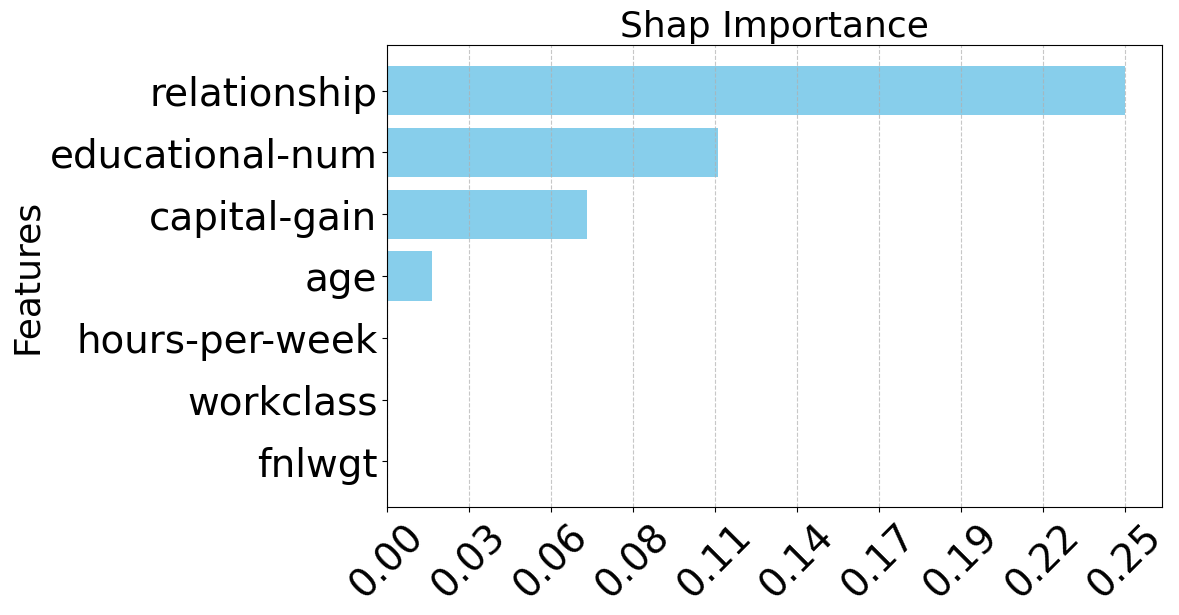

In [7]:
plt.figure(figsize=(10, 6))
plt.barh(shap_top_features[:group_size], shap_top_values[:group_size], color='skyblue')
plt.ylabel('Features', fontsize=26)     
xtick_values = np.linspace(min(shap_top_values), max(shap_top_values), num=10)
plt.xticks(xtick_values, fontsize=28, rotation=45)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.yticks(fontsize=28)
plt.title('Shap Importance', fontsize=26)
plt.gca().invert_yaxis()
plt.margins(x=0.05)
plt.show()


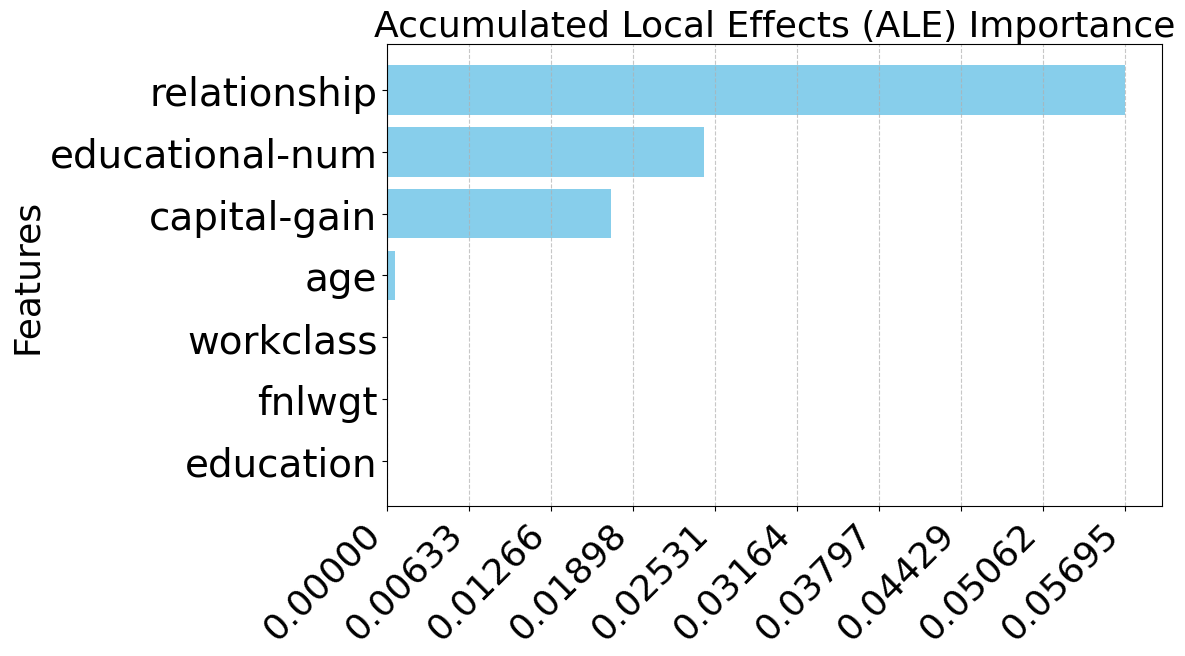

In [8]:
import logging
logging.getLogger('alibi').setLevel(logging.ERROR)

ale_start_time = time.time()  # Start measuring ALE execution time

# Load the dataset from the specified CSV path
ale_data = pd.read_csv(path)
ale_target = ale_data['class']  # Target variable (class labels)
ale_features_all = ale_data.drop(columns=['class'])  # Feature set

# Split the data into training and testing sets (ALE-specific)
X_train_ale, X_test_ale, y_train_ale, y_test_ale = train_test_split(
    ale_features_all, ale_target, test_size=0.2, random_state=42
)

# Preprocessor: pass through numeric columns as they are
ale_numeric_cols = ale_features_all.select_dtypes('number').columns
ale_preprocessor = ColumnTransformer([('num', 'passthrough', ale_numeric_cols)])

# Create a pipeline combining preprocessing and the model
ale_model_pipeline = Pipeline([
    ('prep', ale_preprocessor),
    ('clf', deepcopy(pick_mdl))  # Use a copy of the selected model
])

# Fit the model pipeline to the training data
ale_model_pipeline.fit(X_train_ale, y_train_ale)

# Define the prediction function for the ALE explainer
def ale_predict_fn(X_array):
    X_df = pd.DataFrame(X_array, columns=ale_features_all.columns)
    return ale_model_pipeline.predict_proba(X_df)

# Initialize the ALE (Accumulated Local Effects) explainer
ale_explainer = ALE(
    predictor=ale_predict_fn,  # Prediction function
    feature_names=ale_features_all.columns.tolist(),  # Feature names
    target_names=['neg', 'pos']  # Class names
)

# Generate grid points for each feature (20 points per feature)
ale_grid_resolution = 20
ale_feature_indices = list(range(X_test_ale.shape[1]))
ale_grid_points = {
    idx: np.linspace(
        X_test_ale.values[:, idx].min(),
        X_test_ale.values[:, idx].max(),
        ale_grid_resolution
    )
    for idx in ale_feature_indices
}

# Compute ALE explanations for the test data
ale_exp = ale_explainer.explain(
    X_test_ale.values,
    features=ale_feature_indices,
    grid_points=ale_grid_points
)

# Calculate feature importance based on the variance of ALE values
ale_variances = [np.var(vals[:, 1]) for vals in ale_exp.ale_values]
ale_feature_importance_df = pd.DataFrame({'ale_importance': ale_variances}, index=ale_features_all.columns)
ale_feature_importance_df.sort_values('ale_importance', ascending=False, inplace=True)

# Select the top k most important features
k = group_size  # Number of top features to select
ale_top_features = ale_feature_importance_df.index.tolist()[:k]  # Top k feature names
ale_top_importance_values = ale_feature_importance_df['ale_importance'].tolist()[:k]  # Corresponding importance scores

# Plot a horizontal bar chart of the top features and their ALE importance
plt.figure(figsize=(10,6))
plt.barh(ale_top_features, ale_top_importance_values, color='skyblue')
plt.ylabel('Features', fontsize=26)
xticks = np.linspace(min(ale_top_importance_values), max(ale_top_importance_values), 10)
plt.xticks(xticks, fontsize=26, rotation=45, ha='right')
plt.yticks(fontsize=28)
plt.title('Accumulated Local Effects (ALE) Importance', fontsize=26)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.show()

# Evaluate model accuracy using the selected top features
ale_acc = compute_accuracy(path, ale_top_features, deepcopy(pick_mdl))

# Calculate total ALE execution time
t_ale = time.time() - ale_start_time

ale_dict = dict(zip(ale_top_features, ale_top_importance_values))

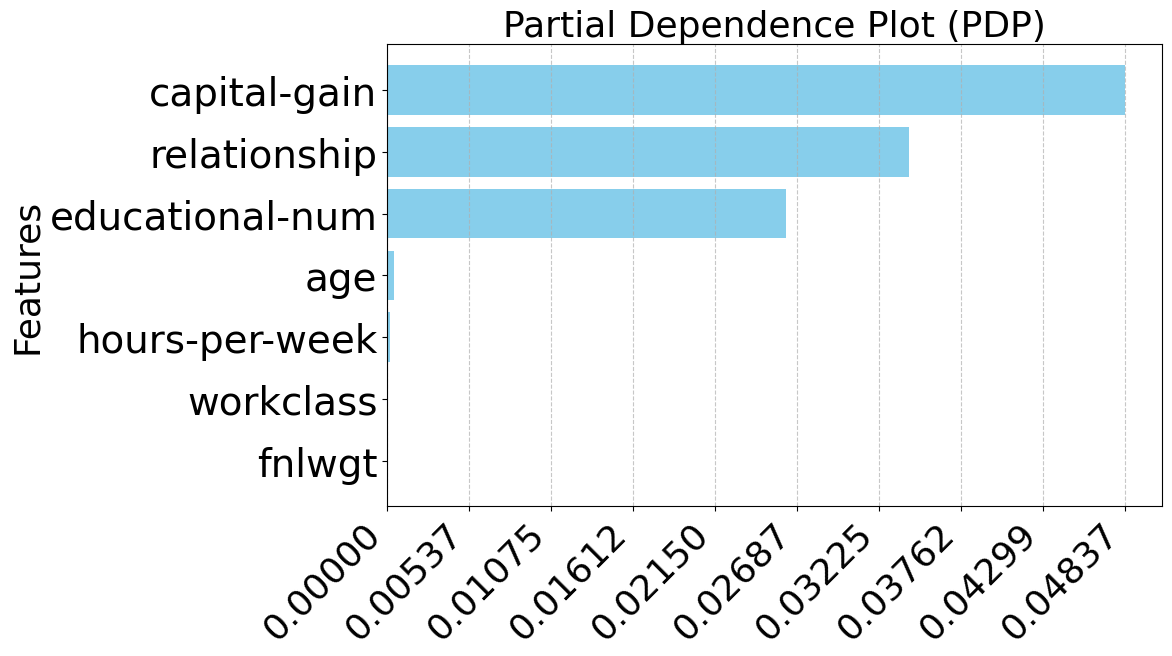

In [9]:
start_pdp = time.time()

# Load the dataset
pdp_data = pd.read_csv(path)

# Separate target variable and features
pdp_target = pdp_data['class'].copy()
pdp_features = pdp_data.drop(columns=['class']).copy()

# Split into training and test sets (PDP-specific)
X_train_pdp, X_test_pdp, y_train_pdp, y_test_pdp = train_test_split(pdp_features, pdp_target, test_size=0.2, random_state=42)

# Identify categorical and numerical columns
pdp_categorical_cols = pdp_features.select_dtypes(include=['object', 'category']).columns.tolist()
pdp_numerical_cols = [c for c in pdp_features.columns if c not in pdp_categorical_cols]

# Preprocessor: Pass numerical columns through without encoding
pdp_preprocessor = ColumnTransformer([
    ('num', 'passthrough', pdp_numerical_cols)
])

# Build the pipeline: preprocessing + classifier
pdp_pipeline = Pipeline([
    ('preproc', pdp_preprocessor),
    ('clf', deepcopy(pick_mdl))
])
pdp_pipeline.fit(X_train_pdp, y_train_pdp)

# Manually compute Partial Dependence Plots (PDP)
pdp_importance_values = []
pdp_feature_names = pdp_features.columns.tolist()
pdp_grid_resolution = 20

for feature in pdp_feature_names:
    if pdp_features[feature].dtype.kind in 'biufc':
        grid = np.linspace(pdp_features[feature].min(), pdp_features[feature].max(), pdp_grid_resolution)
    else:
        grid = np.unique(pdp_features[feature])
    
    pdp_means = []
    for val in grid:
        X_temp_pdp = X_test_pdp.copy()
        X_temp_pdp[feature] = val
        preds = pdp_pipeline.predict_proba(X_temp_pdp)[:, 1]
        pdp_means.append(preds.mean())
    
    pdp_importance_values.append(np.var(pdp_means))

# Create DataFrame of feature importances and sort
pdp_importance_df = pd.DataFrame({
    'feature_importance': pdp_importance_values
}, index=pdp_feature_names).sort_values('feature_importance', ascending=False)

# Extract top k features and their importance values
top_pdp_features = pdp_importance_df.index.tolist()[:group_size]
top_pdp_values = pdp_importance_df['feature_importance'].tolist()[:group_size]

# Plot bar chart for the top k features
plt.figure(figsize=(10, 6))
plt.barh(pdp_importance_df.index[:group_size], pdp_importance_df['feature_importance'][:group_size], color='skyblue')
plt.ylabel('Features', fontsize=26)
xtick_values = np.linspace(min(top_pdp_values), max(top_pdp_values), num=10)
plt.xticks(xtick_values, fontsize=26, rotation=45, ha='right')
plt.title('Partial Dependence Plot (PDP)', fontsize=26)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.yticks(fontsize=28)
plt.gca().invert_yaxis()
plt.show()

# Prepare selected features for accuracy testing
pdp_selected_features = top_pdp_features[:group_size]
pdp_selected_features.sort()
pdp_selected_features.append('class')

# Compute accuracy for the selected features
pdp_acc = str(compute_accuracy(path, pdp_selected_features, deepcopy(pick_mdl))).replace('.', ',')

# Calculate execution time
end_pdp = time.time()
t_pdp = end_pdp - start_pdp

# Create dictionary of PDP feature importances
pdp_dict = dict(zip(top_pdp_features, top_pdp_values))


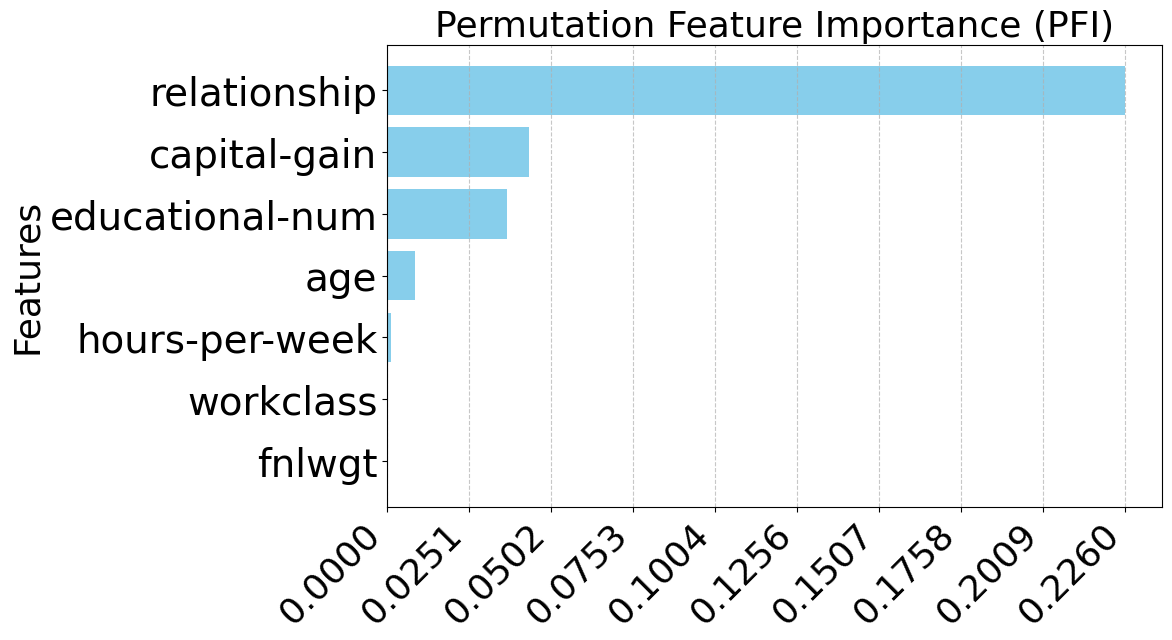

In [10]:
pfi_start_time = time.time()

# Load the dataset
pfi_data = pd.read_csv(path)

# Separate target variable and features
pfi_target = pfi_data['class'].copy()
pfi_features = pfi_data.drop(columns=['class']).copy()

# Split data into training and test sets (PFI-specific)
X_train_pfi, X_test_pfi, y_train_pfi, y_test_pfi = train_test_split(pfi_features, pfi_target, test_size=0.2, random_state=42)

# Train the model (PFI-specific)
pfi_model = deepcopy(pick_mdl)
pfi_model.fit(X_train_pfi, y_train_pfi)

# Calculate Permutation Importance
pfi_importance = permutation_importance(
    pfi_model, X_test_pfi, y_test_pfi, n_repeats=10, random_state=42, n_jobs=-1
)

# Create a DataFrame for feature importances and sort descending
pfi_importance_df = pd.DataFrame(
    pfi_importance.importances_mean,
    index=pfi_features.columns,
    columns=['feature_importance']
)
pfi_importance_df.sort_values(by='feature_importance', ascending=False, inplace=True)

# Extract top features and their importance values
pfi_top_features = pfi_importance_df.index.tolist()[:group_size]
pfi_top_values = pfi_importance_df['feature_importance'].tolist()[:group_size]

# Plot Permutation Importance
plt.figure(figsize=(10, 6))
plt.barh(pfi_importance_df.index[:group_size], pfi_importance_df['feature_importance'][:group_size], color='skyblue')
plt.ylabel('Features', fontsize=26)
pfi_xtick_values = np.linspace(min(pfi_top_values), max(pfi_top_values), num=10)
plt.xticks(pfi_xtick_values, fontsize=26, rotation=45, ha='right')
plt.title('Permutation Feature Importance (PFI)', fontsize=26)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.yticks(fontsize=28)
plt.gca().invert_yaxis()
plt.show()

# Prepare selected features for accuracy testing
pfi_selected_features = pfi_top_features
pfi_selected_features.sort()
pfi_selected_features.append('class')

# Compute accuracy for the selected features
pfi_acc = str(compute_accuracy(path, pfi_selected_features, deepcopy(pick_mdl))).replace('.', ',')

# Calculate total execution time
t_pfi = time.time() - pfi_start_time

# Create dictionary of PFI feature importances
pfi_dict = dict(zip(pfi_top_features, pfi_top_values))


In [11]:
def featureAcc(d_f, model, feature):
    dataf = d_f.loc[:, feature].copy()
    y = dataf["class"]
    X = dataf.drop(columns=["class"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc



t_sc= myClass.alg_consistency

In [ ]:
# Function to evaluate Fidelity
def evaluate_fidelity(
    model,
    X_train,
    X_test,
    importance_scores,
    top_k=7,
    metric='accuracy',
    max_depth='auto',
    random_state=42,
    verbose=False,
    epsilon=1e-3,
    normalize=False,
):
    # 1) Convert importance scores to a pandas Series
    imp = pd.Series(importance_scores, index=X_train.columns,
                    name='Importance', dtype=float)
    if normalize:
        max_abs = imp.abs().max()
        if max_abs > 0:
            imp = imp / max_abs

    # 2) Filter features with importance above epsilon
    imp_abs = imp.abs()
    imp_filtered = imp_abs[imp_abs > epsilon]
    if imp_filtered.empty:
        if verbose:
            print(f"No features above |epsilon|={epsilon}, falling back.")
        imp_filtered = imp_abs

    # 3) Select top-k most important features
    top_feats = imp_filtered.sort_values(ascending=False)\
                             .head(top_k).index.tolist()
    if verbose:
        print("Features used:", top_feats)

    # 4) Get predictions of the black-box model
    y_bb_train = model.predict(X_train)
    y_bb_test  = model.predict(X_test)

    # 5) Choose the best depth for the surrogate model (DecisionTree)
    if max_depth == 'auto':
        param_grid = {'max_depth': list(range(2, 11))}
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        gs = GridSearchCV(
            DecisionTreeClassifier(random_state=random_state),
            param_grid,
            scoring='accuracy',
            cv=cv,
            n_jobs=-1
        )
        gs.fit(X_train[top_feats], y_bb_train)
        best_depth = gs.best_params_['max_depth']
    else:
        best_depth = max_depth
    if verbose:
        print(f"Chosen max_depth: {best_depth}")

    # 6) Train the surrogate model on top-k features
    surrogate = DecisionTreeClassifier(max_depth=best_depth, random_state=random_state)
    surrogate.fit(X_train[top_feats], y_bb_train)

    # 7) Calculate fidelity (accuracy or F1 between surrogate and black-box predictions)
    y_surr = surrogate.predict(X_test[top_feats])
    if metric == 'accuracy':
        fidelity = accuracy_score(y_bb_test, y_surr)
    else:
        fidelity = f1_score(y_bb_test, y_surr, average='weighted')
    if verbose:
        print(f"Fidelity: {fidelity:.4f}")

    return fidelity, surrogate

# Function to evaluate Faithfulness
# ICE-based faithfulness (plain-language explanation)
# --------------------------------------------------
# Goal: quantify how well an explanation method’s global feature-importance ranking
# matches the model’s feature-wise output sensitivity estimated via ICE.
#
# For each feature f:
#   1) Choose a reasonable value range for f from the training data (e.g., 5th–95th percentile).
#   2) Build a small grid of values within this range.
#   3) For each grid value v:
#        - Create a copy of the test set
#        - Set column f to v for ALL test rows (keep all other features unchanged)
#        - Compute model output (e.g., target-class probability)
#      This yields an ICE curve per test instance.
#   4) Summarize sensitivity for f as “how much predictions vary across the ICE curve”
#      (e.g., average per-instance variance across the grid).
#
# Faithfulness score:
#   - Compare the explanation method’s importance scores with the ICE sensitivity scores
#     using a rank-agreement measure (typically Spearman correlation).
#   - Higher score => features marked as important by the explainer are also the ones
#     that most strongly move the model output when varied.
#
# Note:
#   - This measures output-sensitivity alignment (a score-level faithfulness notion),
#     not necessarily performance-drop faithfulness (accuracy/log-loss drop).

def evaluate_faithfulness(
    model,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    importance_scores: dict,
    top_k: int = 7,
    metric: str = 'accuracy',
    random_state: int = 42,
    runs_per_feature: int = 10,
    epsilon: float = 1e-8,
    normalize: bool = False,
    verbose: bool = False,
    grid_resolution: int = 30,
    pdp_percentiles: tuple = (0.05, 0.95),
):
    """
    Calculates faithfulness via feature permutation (shuffle) and Spearman correlation.
    Returns:
    - faithfulness: Spearman correlation between importance and performance drop
    - drop_impacts: Dictionary of performance drop per feature
    """
    # 1) Prepare absolute importances and filter insignificant features
    imp = pd.Series(importance_scores, dtype=float)
    if normalize:
        max_abs = imp.abs().max()
        if max_abs > 0:
            imp = imp / max_abs
    imp_abs = imp.abs()
    mask = imp_abs > epsilon
    features = (
        imp_abs.loc[mask].nlargest(top_k).index.tolist()
        if mask.any() and top_k and top_k < mask.sum()
        else imp_abs.loc[mask].index.tolist() if mask.any()
        else imp.index.tolist()
    )
    if verbose:
        print(f"Selected {len(features)} features:")
        for f in features:
            print(f" - {f}: importance {imp[f]:.4f}")

    # 2) Get base performance (accuracy or F1)
    y_pred_base = model.predict(X_test)
    scorer = accuracy_score if metric == 'accuracy' else (lambda y, yp: f1_score(y, yp, average='weighted'))
    base_score = scorer(y_test, y_pred_base)
    if verbose:
        print(f"Base {metric}: {base_score:.4f}")

    # 3) Measure performance drop when shuffling each feature
    rng = np.random.RandomState(random_state)
    drop_impacts = {}
    for feat in features:
        impacts = []
        for _ in range(runs_per_feature):
            X_shuffled = X_test.copy()
            col = X_shuffled[feat].to_numpy().copy()
            rng.shuffle(col)
            X_shuffled[feat] = col
            y_pred_shuf = model.predict(X_shuffled)
            impacts.append(base_score - scorer(y_test, y_pred_shuf))
        drop_impacts[feat] = float(np.mean(impacts))
        if verbose:
            print(f"Impact {feat}: {drop_impacts[feat]:.4f}")

    # 4) Calculate ICE-based global variance for each feature
    ice_var_importances = {}
    low_pct, high_pct = pdp_percentiles
    for feat in features:
        low = X_train[feat].quantile(low_pct)
        high = X_train[feat].quantile(high_pct)
        grid = np.linspace(low, high, grid_resolution)
        ice_vals = np.zeros((len(X_test), len(grid)))
        for i, val in enumerate(grid):
            X_temp = X_test.copy()
            X_temp[feat] = val
            if hasattr(model, 'predict_proba'):
                preds = model.predict_proba(X_temp)
                y_vals = preds[:, 1] if preds.shape[1] > 1 else preds[:, 0]
            else:
                y_vals = model.predict(X_temp)
            ice_vals[:, i] = y_vals
        ice_var_importances[feat] = float(np.mean(np.var(ice_vals, axis=1)))
        if verbose:
            print(f"ICE-var importance {feat}: {ice_var_importances[feat]:.4f}")

    # 5) Spearman correlation between ICE importance and performance drops
    imp_vals = [ice_var_importances[f] for f in features]
    impact_vals = [drop_impacts[f] for f in features]
    if len(set(imp_vals)) <= 1 or len(set(impact_vals)) <= 1:
        faithfulness = 0.0
        if verbose:
            print("No variance to compute correlation.")
    else:
        faithfulness, _ = spearmanr(imp_vals, impact_vals)
        if verbose:
            print(f"Faithfulness (Spearman): {faithfulness:.4f}")

    return faithfulness, drop_impacts

# Example usage: Testing multiple importance methods (val_impact, SHAP, PDP, PFI, ALE)
if __name__ == '__main__':
    data = pd.read_csv(path)
    y = data['class']
    X = data.drop(columns=['class'])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    bb_model = deepcopy(pick_mdl)
    bb_model.fit(X_train, y_train)

    fidel_fix, _ = evaluate_fidelity(bb_model, X_train, X_test, val_impact_dict)
    faith_fix, _ = evaluate_faithfulness(bb_model, X_train, y_train, X_test, y_test, val_impact_dict)
    fidel_shap, _ = evaluate_fidelity(bb_model, X_train, X_test, shap_dict)
    faith_shap, _ = evaluate_faithfulness(bb_model, X_train, y_train, X_test, y_test, shap_dict)
    fidel_pdp, _ = evaluate_fidelity(bb_model, X_train, X_test, pdp_dict)
    faith_pdp, _ = evaluate_faithfulness(bb_model, X_train, y_train, X_test, y_test, pdp_dict)
    fidel_pfi, _ = evaluate_fidelity(bb_model, X_train, X_test, pfi_dict)
    faith_pfi, _ = evaluate_faithfulness(bb_model, X_train, y_train, X_test, y_test, pfi_dict)
    fidel_ale, _ = evaluate_fidelity(bb_model, X_train, X_test, ale_dict)
    faith_ale, _ = evaluate_faithfulness(bb_model, X_train, y_train, X_test, y_test, ale_dict)

In [13]:
#Calculating the running time of the our algorithm
startTime = time.time()
myClass.prepare_data()
myClass.select_features()
myClass.combFeatures()
endTime=time.time()
t1 = endTime - startTime
print("Time:",round(t1,2))

feature_combination_acc Function Activated: Creating combinations of important attributes by adding model score values...
grouped_weights_valimp Function Activated: Calculating weights of Important Features...
grouped_weights Function Activated: Calculating weights of Important Features...
weighticient and Accuracy Calculated. Data Groups Created According to the Number of Combinational Elements...
Time: 3.2


In [14]:
def bold_(text):
    return(f"\033[1m{text}\033[0m")

all_accuracy = compute_accuracy(path, None, deepcopy(pick_mdl))

In [15]:
print(bold_("Number of Data: "), myClass.num_of_data)
print(bold_("Number of Class: "), myClass.num_of_class)
print(bold_("Number of Features: "), myClass.num_of_feature)
print(bold_("Selected Model : "),type(pick_mdl).__name__)
print("\n")

print(bold_("fixAIt Algorithm"))
print(bold_("\t\u2193"))
print(bold_("Selected features: "),myClass.features)
print(bold_("Accuracy value of selected features: "), myClass.acc_select)
print(bold_("Accuracy value of all features: "), all_accuracy)
print(f'fiXAIt → Fidelity: {fidel_fix:.4f} | Faithfulness: {faith_fix:.4f}')
print(bold_("fiXAIt Self-Consistency: "), round(t_sc,3))
print(bold_("Algorithm Run Time (sec): "), round(t1,2))

print("\n")
print(bold_("SHAP Algorithm"))
print(bold_("\t\u2193"))
print(bold_("Selected features: "),shap_selected_features[:-1])
print(bold_("Accuracy value of selected features: "), shap_acc)
print(bold_("Accuracy value of all features: "), all_accuracy)
print(f'Shap → Fidelity: {fidel_shap:.4f} | Faithfulness: {faith_shap:.4f}')
print(bold_("Algorithm Run Time (sec): "), round(t_shap,2))

print("\n")
print(bold_("ALE Algorithm"))
print(bold_("\t\u2193"))
print(bold_("Selected features: "),ale_top_features[:-1])
print(bold_("Accuracy value of selected features: "), ale_acc)
print(bold_("Accuracy value of all features: "), all_accuracy)
print(f'ALE → Fidelity: {fidel_ale:.4f} | Faithfulness: {faith_ale:.4f}')
print(bold_("Algorithm Run Time (sec): "), round(t_ale,2))

print("\n")
print(bold_("PDP Algorithm"))
print(bold_("\t\u2193"))
print(bold_("Selected features: "),pdp_selected_features[:-1])
print(bold_("Accuracy value of selected features: "), pdp_acc)
print(bold_("Accuracy value of all features: "), all_accuracy)
print(f'\nPDP → Fidelity: {fidel_pdp:.4f} | Faithfulness: {faith_pdp:.4f}')
print(bold_("Algorithm Run Time (sec): "), round(t_pdp,2))

print("\n")
print(bold_("PFI Algorithm"))
print(bold_("\t\u2193"))
print(bold_("Selected features: "),pfi_selected_features[:-1])
print(bold_("Accuracy value of selected features: "), pfi_acc)
print(bold_("Accuracy value of all features: "), all_accuracy)
print(f'PFI → Fidelity: {fidel_pfi:.4f} | Faithfulness: {faith_pfi:.4f}')
print(bold_("Algorithm Run Time (sec): "), round(t_pfi,2))

Number of Data:  23100
Number of Class:  2
Number of Features:  14
Selected Model :  DecisionTreeClassifier


fixAIt Algorithm
	↓
Selected features:  ['age', 'capital-gain', 'educational-num', 'gender', 'hours-per-week', 'marital-status', 'relationship']
Accuracy value of selected features:  0.807
Accuracy value of all features:  0.807
fiXAIt → Fidelity: 1.0000 | Faithfulness: 0.8602
fiXAIt Self-Consistency:  0.766
Algorithm Run Time (sec):  3.2


SHAP Algorithm
	↓
Selected features:  ['age', 'capital-gain', 'educational-num', 'fnlwgt', 'hours-per-week', 'relationship', 'workclass']
Accuracy value of selected features:  0,807
Accuracy value of all features:  0.807
Shap → Fidelity: 1.0000 | Faithfulness: 0.8000
Algorithm Run Time (sec):  6.79


ALE Algorithm
	↓
Selected features:  ['relationship', 'educational-num', 'capital-gain', 'age', 'workclass', 'fnlwgt']
Accuracy value of selected features:  0.807
Accuracy value of all features:  0.807
ALE → Fidelity: 0.9926 | Faithfulness: 0.800